### Initialization

In [1]:
from astropy.cosmology import FlatLambdaCDM
from astropy.units import Quantity
from astropy import units

# from slsim.Lenses.lens_pop import LensPop
import numpy as np

# import corner
import matplotlib.pyplot as plt

# from scipy import stats
# import pandas as pd
# from distfit import distfit
# from matplotlib.ticker import NullFormatter
# import seaborn as sns
# from collections import Counter

from slsim.Sources.Events.BNSMerger.bns_merger_pop import BNSMergerRate
from slsim.Sources.Events.BNSMerger.bns_merger_pop import norm_delay_time_distribution

from slsim.Sources.Events.Supernovae.supernovae_pop import SNIaRate
from slsim.Sources.Events.Supernovae.supernovae_pop import calculate_star_formation_rate
from slsim.Sources.Events.Supernovae.supernovae_pop import delay_time_distribution

from slsim.Sources.Events.event_pop import EventPopulation
from slsim.Sources.Events.event_lightcone import EventLightcone

In [2]:
def plot(x, y, x_label, y_label, title, color, legend, label):
    plt.plot(x, y, color=color, label=label)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def semilog(x, y, x_label, y_label, title, color, legend, label):
    plt.semilogy(x, y, color=color, label=label)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def hist(x, x_label, y_label, title, legend, label, bins, color):
    plt.hist(x, bins=bins, label=label, color=color)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)


def scatter(x, y, x_label, y_label, title, legend, label, color):
    plt.scatter(x, y, label=label, color=color, s=10)
    plt.xlabel(x_label, fontsize=15)
    plt.ylabel(y_label, fontsize=15)
    plt.xticks(fontsize=15)
    plt.yticks(fontsize=15)
    plt.title(title, fontsize="15")
    if legend:
        plt.legend(fontsize=15)

## Event Population Overview

In this overview notebook, we illustrate the implementation of event populations and analyze their distributions, using BNS mergers and Type Ia supernovae as examples.

1. Number density calculation\
    1.1 BNS merger event rate calculation (BNSMergerRate Class)\
    1.2 Type Ia supernova event rate calculation (SNIaRate Class)\
    1.3 Unified event population interface (EventPopulation Class)

2. Lightcone integration (EventLightcone Class)

## Number Density Calculation

### Initialize the BNSMergerRate Class

In [3]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
bns_rate = BNSMergerRate(cosmo, 10)

### BNS Merger Plots

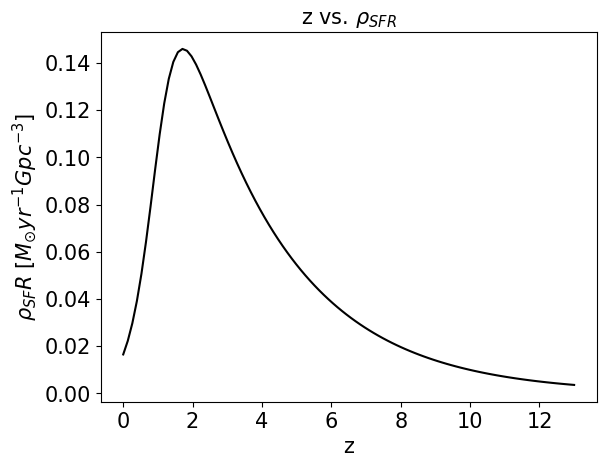

In [4]:
# Define array of redshifts
z_array = np.linspace(0, 13, 100)
rate_list = []

# Calculate binary formation rate given redshift using the function 'calculate_star_formation_rate'
for i in np.arange(100):
    rate_list.append(bns_rate.binary_formation_rate(z_array[i]))

# Plot binary formation rate as a function of redshift
plot(
    z_array,
    rate_list,
    "z",
    r"$\rho_{SF}R$ $[ M_{\odot} yr^{-1}Gpc^{-3}]$",
    "z vs. " r"$\rho_{SFR}$",
    "black",
    False,
    "n/a",
)

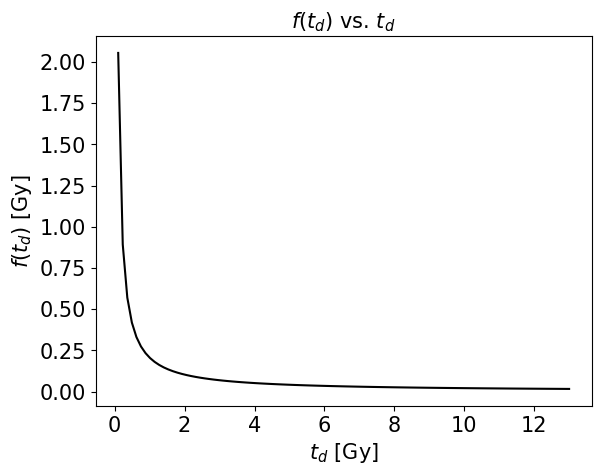

In [5]:
# Define array of time delays
t_d_array = np.linspace(0.1, 13, 100)
dist_list = []

# Calculate time delay distribution given time delay using the function 'norm_delay_time_distribution'
for i in np.arange(100):
    dist_list.append(
        norm_delay_time_distribution(t_d_array[i], min(t_d_array), max(t_d_array))
    )

# Plot time delay distribution as a function of time delay
plot(
    t_d_array,
    dist_list,
    r"$t_{d}$ [Gy]",
    r"$f(t_{d})$ [Gy]",
    "$f(t_{d})$ vs. $t_{d}$",
    "black",
    False,
    "n/a",
)

### Initialize the SNIaRate Class

In [6]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
sne_rate = SNIaRate(cosmo, 10)

### SN Ia Plots

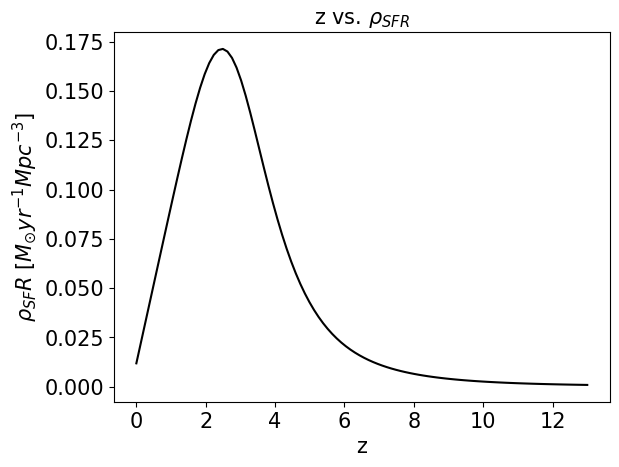

In [7]:
# Define array of redshifts
z_array = np.linspace(0, 13, 100)
rate_list = []

# Calculate star formation rate given redshift using the function 'calculate_star_formation_rate'
for i in np.arange(100):
    rate_list.append(calculate_star_formation_rate(z_array[i]))

# Plot star formation rate as a function of redshift
plot(
    z_array,
    rate_list,
    "z",
    r"$\rho_{SF}R$ $[ M_{\odot} yr^{-1}Mpc^{-3}]$",
    "z vs. " r"$\rho_{SFR}$",
    "black",
    False,
    "n/a",
)

/Users/mia/SLSim/slsim/slsim/Sources/Events/Supernovae/supernovae_pop.py:28: RuntimeWarning: divide by zero encountered in scalar power
  ft_d = (t_d) ** (-1.08)


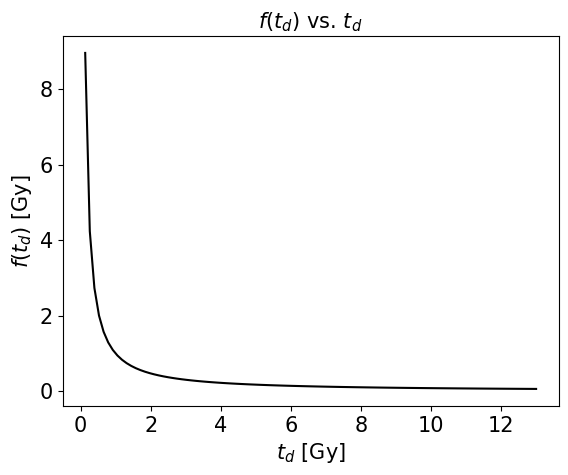

In [8]:
# Define array of time delays
t_d_array = np.linspace(0, 13, 100)
dist_list = []

# Calculate time delay distribution given time delay using the function 'delay_time_distribution'
for i in np.arange(100):
    dist_list.append(delay_time_distribution(t_d_array[i]))

# Plot time delay distribution as a function of time delay
plot(
    t_d_array,
    dist_list,
    r"$t_{d}$ [Gy]",
    r"$f(t_{d})$ [Gy]",
    "$f(t_{d})$ vs. $t_{d}$",
    "black",
    False,
    "n/a",
)

### Initialize the EventPopulation Class

In [10]:
cosmo = FlatLambdaCDM(70, 0.3)

# Initialize the class
event_rate = EventPopulation("BNS", cosmo, 10)

### Plot Redshift As a Function of Time

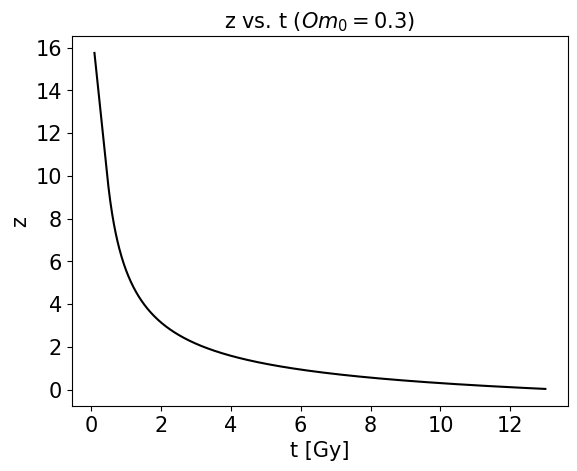

In [11]:
# Define array of times
t_array = np.linspace(0.1, 13, 1000)

# Calculate redshift given time
z_list = event_rate._z_from_time(t_array)

# Plot redshift as a function of time
plot(
    t_array,
    z_list,
    "t [Gy]",
    "z",
    "z vs. t $(Om_{0} = 0.3)$",
    "black",
    False,
    r"$H_{0}$=70",
)

### Number Density

/Users/mia/SLSim/slsim/slsim/Sources/Events/BNSMerger/bns_merger_pop.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  numerator = integrate.quad(
/Users/mia/SLSim/slsim/slsim/Sources/Events/BNSMerger/bns_merger_pop.py:118: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  unorm_BNS_rate_z0 = integrate.quad(


(0.0, 4.0)

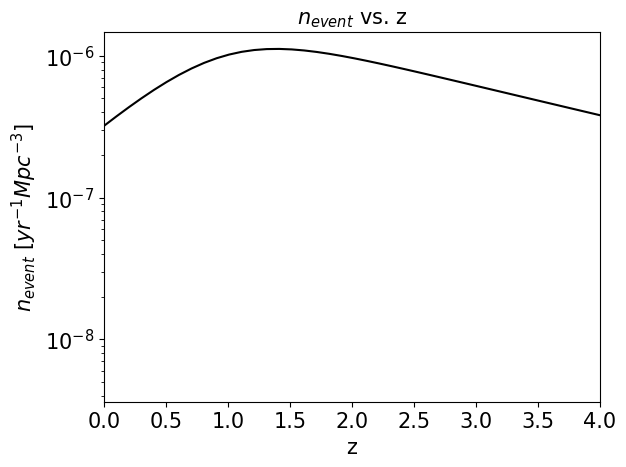

In [12]:
# Define array of redshifts
z_array = np.linspace(0, 10, 100)

# Calculate density given redshift using the class function 'event_rate'
density_list = event_rate.event_rate(z_array)

# Plot number density vs. redshift
semilog(
    z_array,
    density_list,
    "z",
    r"$n_{event}$ $[yr^{-1}Mpc^{-3}]$",
    "$n_{event}$ vs. z",
    "black",
    False,
    r"$H_{0}$=70",
)
plt.xlim(0, 4)
# plt.ylim(10e-6, 10e-4)

## Lightcone Integration

(126,)


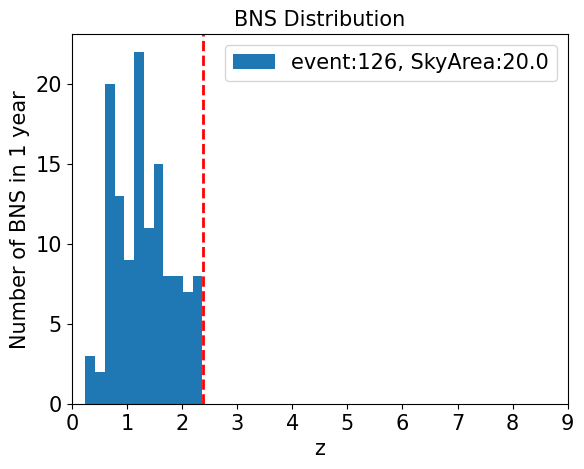

In [13]:
# Define a cosmology
cosmo = FlatLambdaCDM(70, 0.3)

# Define redshift range of the lightcone (at the moment, i-band lightcurve upper limit = 2.379)
redshifts = np.linspace(0, 2.379, 50)

# Define sky area of the lightcone
sky_area = Quantity(value=20, unit="deg2")

# Consider noise in lightcone integration
noise = True

# Choose a model for lightcone calculation
# model = "SNIa"
model = "BNS"

# Define a time interval of the lightcone
time_interval = 1 * units.year

# Initialize lightcone class
event_lightcone = EventLightcone(
    cosmo, redshifts, sky_area, noise, time_interval, model
)

# Generate supernovae catalog within the initialized lightcone using the class function 'supernovae_sample'
lightcone_array = event_lightcone.event_sample()

# Plot histogram of the number of obtained supernovae within the lightcone as a function of redshift
label = "event:{}, SkyArea:{}".format(len(lightcone_array), sky_area.value)
label_y = "Number of " + model + " in 1 year"
caption = model + " Distribution"

hist(
    lightcone_array,
    "z",
    label_y,
    caption,
    True,
    label,
    12,
    None,
)
plt.xlim(0, 9)

# Include i-band lightcurve cutoff line on the plot for clarity
plt.axvline(x=2.379, color="red", linestyle="--", linewidth=2)

print(np.shape(lightcone_array))